# K MEANS ELBOW AND CLUSTERS.PY

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# DATA

In [3]:
points = np.array([
    [1,2],
    [1,4],
    [1,0],
    [5,2],
    [5,4],
    [6,2]
], dtype = float)
labels = ["A","B","C","D","E","F"]

In [4]:
ks = [1,2,3,4]
sse = []
for k in ks:
    km = KMeans(n_clusters = k , random_state = 42 , n_init = 50)
    km.fit(points)
    sse.append(km.inertia_)
    print(f"k = {k} SSE (Inertia) = {km.inertia_:.6f}")

k = 1 SSE (Inertia) = 40.166667
k = 2 SSE (Inertia) = 11.333333
k = 3 SSE (Inertia) = 5.333333
k = 4 SSE (Inertia) = 2.500000


# PLOT

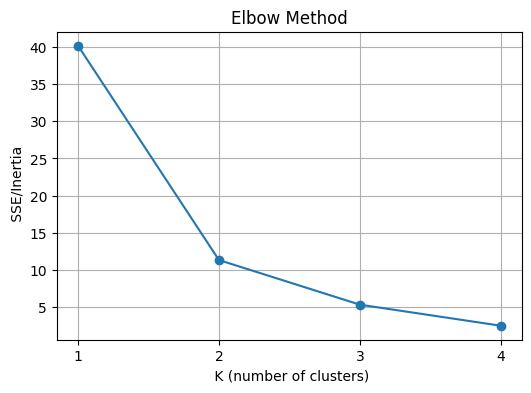

In [6]:
plt.figure(figsize = (6,4))
plt.plot(ks , sse , '-o')
plt.xticks(ks)
plt.xlabel(' K (number of clusters)')
plt.ylabel(' SSE/Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

In [9]:
chosen_k = 2
kmeans = KMeans(n_clusters=chosen_k,random_state=42,n_init=50)
kmeans.fit(points)
clusters = kmeans.labels_
centroids = kmeans.cluster_centers_

print("\n Optional K =",chosen_k)
for i,label in enumerate(labels):
    print(f"Point {label} {tuple(points[i])} -> cluster {clusters[i]}")
print("Centroids",centroids)


 Optional K = 2
Point A (np.float64(1.0), np.float64(2.0)) -> cluster 0
Point B (np.float64(1.0), np.float64(4.0)) -> cluster 0
Point C (np.float64(1.0), np.float64(0.0)) -> cluster 0
Point D (np.float64(5.0), np.float64(2.0)) -> cluster 1
Point E (np.float64(5.0), np.float64(4.0)) -> cluster 1
Point F (np.float64(6.0), np.float64(2.0)) -> cluster 1
Centroids [[1.         2.        ]
 [5.33333333 2.66666667]]


**Plot**

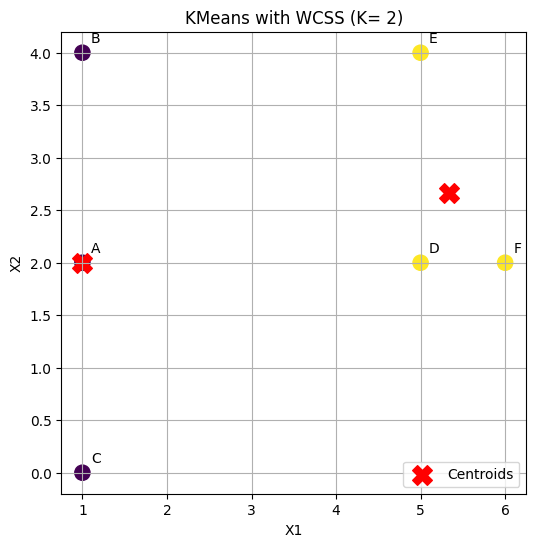

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(points[:,0] , points[:,1],c=clusters,s=120 ,cmap='viridis')
plt.scatter(centroids[:,0],centroids[:,1],marker='X' ,s=200,c='red',label='Centroids')

for i, txt in enumerate(labels):
    plt.annotate(txt,(points[i,0]+0.1, points[i,1]+0.1))
plt.title(f"KMeans with WCSS (K= {chosen_k})")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()    